# Correlation

In [1]:
from pathlib import Path
import sys

sys.path.append(
    str(Path.cwd().parent)
)

In [2]:
from src import (
    retrieve_group,
    generate_correlation_matrix,
    threshold_signed_adjacency,
    plot_correlation_network,
    plot_correlation_matrix,
    save_correlation_matrix,
)

In [3]:
# Decide group
filters = {
    "cntry": {"value": "GB"},
    "title": "GB, Ages 15 to 34",
    "plot_name": "gb_youth"
}

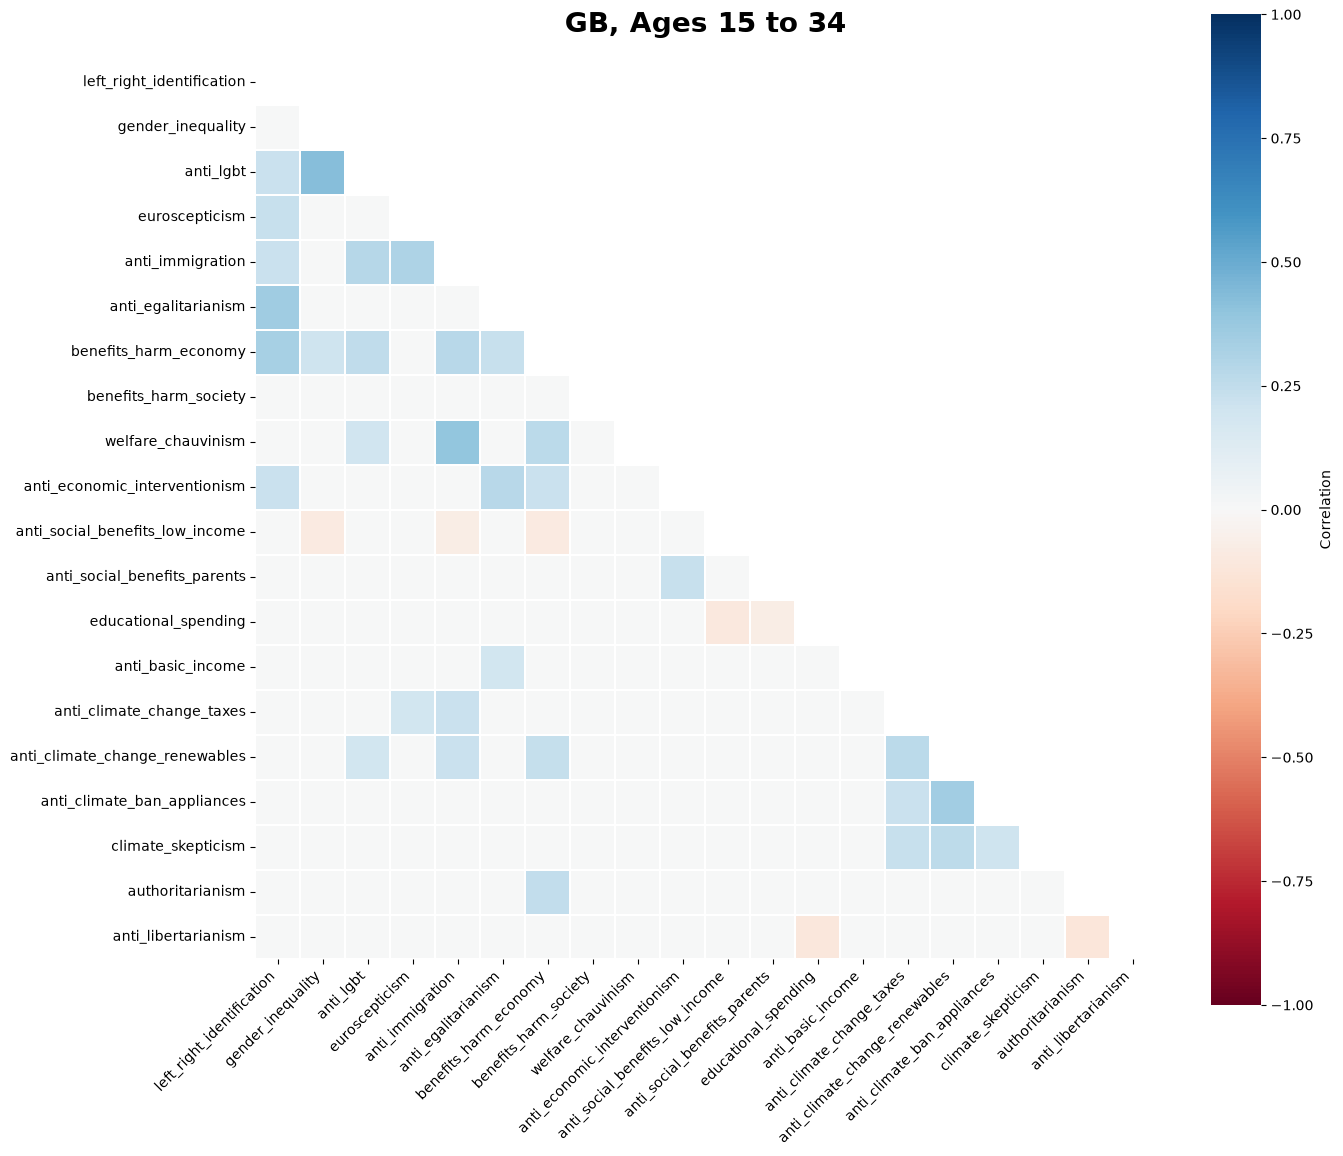

<Axes: title={'center': 'GB, Ages 15 to 34'}>

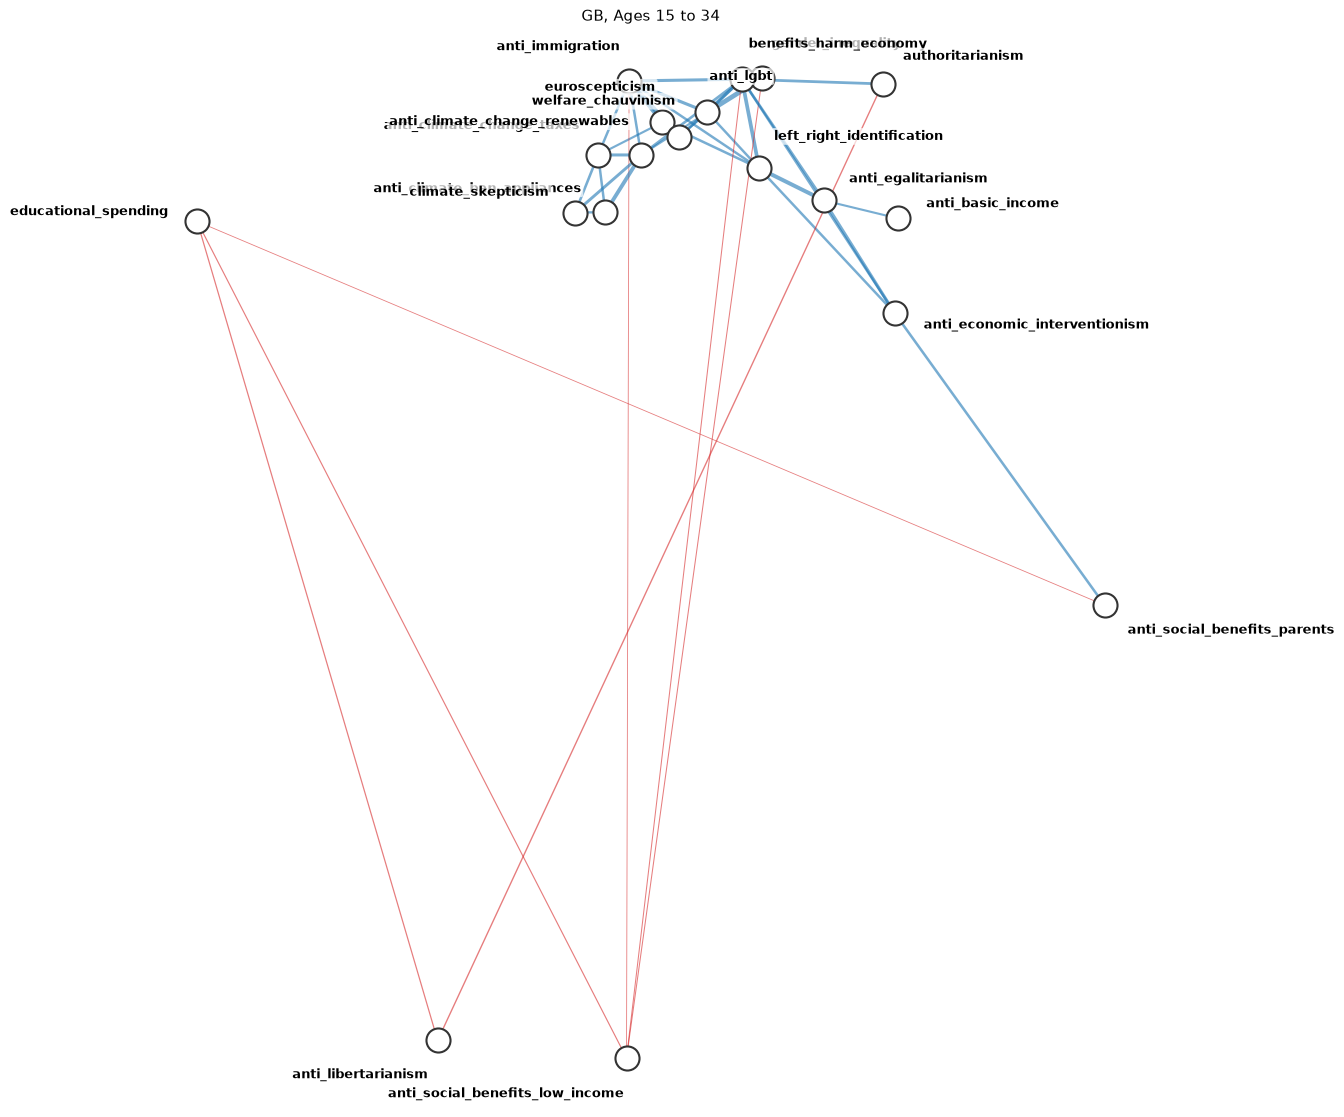

In [ ]:
# Retrieve the respondents belonging to the group
group = retrieve_group(
    csv_path="../input/data/ESS8e02_3_self_processed/ess8_cca_initial_beliefs.csv",
    filters=filters,
)

# Generate the correlation matrix from the selected respondents
corr = generate_correlation_matrix(
    group,
    question_start_col=14,
    question_end_col=34,
    method="pearson",
)

corr_thr, pos_thr, neg_thr = threshold_signed_adjacency(corr, top_percent=50)

plot_name = filters["plot_name"]
title = filters["title"]

# Save the matrix itself
save_correlation_matrix(
    corr_thr,
    f"correlation_matrix_{plot_name}.csv",
)

# Plot the heatmap
plot_correlation_matrix(
    corr_thr,
    title=title,
    output_path=f"../plots/correlation_matrix_{plot_name}.png",
)

# Plot the network
plot_correlation_network(
    corr_thr,
    title=title,
    output_path=f"correlation_network_{plot_name}.png",
)